In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib widget

In [2]:
df=pd.read_csv('linear_regression_dataset.csv')
df

,AGE,FEMALE,LOS,RACE,TOTCHG,APRDRG
0,17,1,2,1.0,2660,560
1,17,0,2,1.0,1689,753
2,17,1,7,1.0,20060,930
3,17,1,1,1.0,736,758
4,17,1,1,1.0,1194,754
...,...,...,...,...,...,...
495,0,1,6,1.0,5881,636
496,0,1,2,1.0,1171,640
497,0,1,2,1.0,1171,640
498,0,1,2,1.0,1086,640


In [4]:
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      1
TOTCHG    0
APRDRG    0
dtype: int64

In [7]:
df['RACE']=df['RACE'].fillna(df['RACE'].mean())
df.isnull().sum()

AGE       0
FEMALE    0
LOS       0
RACE      0
TOTCHG    0
APRDRG    0
dtype: int64

In [10]:
y=df['TOTCHG'].values
X=df.drop(columns=['TOTCHG']).values

In [11]:
X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_norm = (X - X_mean) / X_std

In [12]:
def compute_cost(X, y, w, b):
    m = X.shape[0]
    f_wb = np.dot(X, w) + b
    cost = np.sum((f_wb - y)**2) / (2 * m)
    return cost

In [13]:
def compute_gradient(X, y, w, b):
    m, n = X.shape
    f_wb = np.dot(X, w) + b
    err = f_wb - y
    dj_dw = np.dot(X.T, err) / m
    dj_db = np.sum(err) / m
    return dj_dw, dj_db

In [14]:
def gradient_descent(X, y, w_in, b_in, alpha, num_iters):
    w, b = w_in, b_in
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient(X, y, w, b)
        w -= alpha * dj_dw
        b -= alpha * dj_db
    return w, b

In [15]:
w_init = np.zeros(X_norm.shape[1])
b_init = 0.
w_final, b_final = gradient_descent(X_norm, y, w_init, b_init, 0.1, 1000)

In [16]:
print(f"Final Weights: {w_final}")
print(f"Final Bias: {b_final:.2f}")

Final Weights: [  935.0029649   -195.1485112   2497.04003052  -109.12166779
 -1387.86369428]
Final Bias: 2774.39


In [17]:
# Predict for a patient: Age 17, Female, 3 days stay, Race 1, APRDRG 750
patient = np.array([17, 1, 3, 1, 750])
patient_norm = (patient - X_mean) / X_std
prediction = np.dot(patient_norm, w_final) + b_final
print(f"Predicted Cost: ${prediction:.2f}")

Predicted Cost: $3291.66


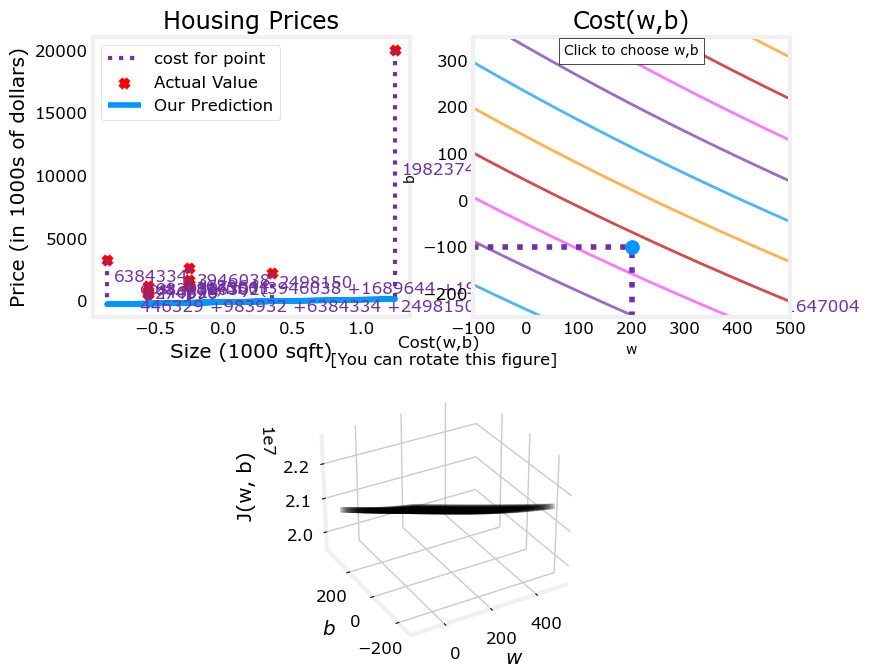

In [20]:
from lab_utils_uni import plt_stationary, plt_update_onclick,soup_bowl

# Pick ONLY Length of Stay (LOS is index 2)
x_plot = X_norm[:10, 2] # Use first 50 rows for clarity
y_plot = y[:10]

plt.close("all")
fig, ax, dyn_items = plt_stationary(x_plot, y_plot)
updater = plt_update_onclick(fig, ax, x_plot, y_plot, dyn_items)

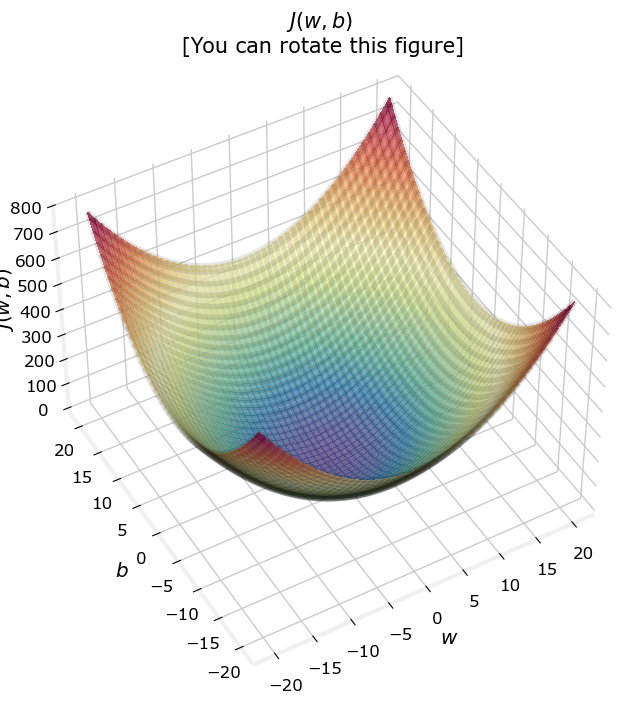

In [21]:
soup_bowl()

In [22]:
y_pred = np.dot(X_norm, w_final) + b_final
ss_res = np.sum((y - y_pred)**2)
ss_tot = np.sum((y - np.mean(y))**2)
r2 = 1 - (ss_res / ss_tot)

print(f"The R-squared value is: {r2:.4f}")

The R-squared value is: 0.5537
